Published on August 18, 2026. By Prata, Marília (mpwolke)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/products_index.csv
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/failed_downloads.csv
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1739/1739.jpg
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1518/1518.jpeg
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1316/1316.jpg
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1535/1535.jpg
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1597/1597.jpg
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1909/1909.jpg
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars/1146/1146.jpg
/kaggle/input/datasets/datascientist97/locomotive-collection-invento

## Locomotive Collection Inventory Images

Dataset's author: Raja Ahmed Ali Khan

Product photos from a model-train inventory system, organized by category

"This dataset contains product photography from a private model-train collection's inventory management system (conductor.fun, built on Zen Cart). Images are organized by category and by the item's real database products_id, collected to train an image-classification model for a
"point your camera at an item, find it in the inventory" visual search feature."

https://www.kaggle.com/datasets/datascientist97/locomotive-collection-inventory-images/data

## Load csv files

In [2]:
df = pd.read_csv('/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/failed_downloads.csv')
df.tail(3)

,products_id,catalog_name,category,image_url_or_reason
8,1772,Santa De Dash 8 40-B 6-18212,Locomotives,images/Santa-De-Dash-8-40-B-6-18212.jpg
9,1540,LGB diesel-locomotive Nichtraucher 2,Freight Cars,images/LGB diesel-locomotive Nichtraucher 2.jpg
10,1536,"LGB R, Vkabj Graines car",Freight Cars,"images/LGB R, Vkabj Graines car.jpg"


In [3]:
df1 = pd.read_csv('/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/products_index.csv')
df1.tail(3)

,products_id,catalog_name,category
835,1972,Southern Pacific searchlight caboose 6-19707.jpg,Freight Cars
836,1973,Southern six wheel crane car 6-19405.jpg,Freight Cars
837,1974,peter,Locomotives


## Impor Libraries

In [5]:
from PIL import Image
import os
from glob import glob
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
#from keras.wrappers.scikit_learn import KerasClassifier #No module named 'keras.wrappers.scikit_learn'
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Count image of each class excluding other kind of files(e.g readme.md)

I asked AI  how to: "Count image of each class excluding readme.md file python"

In [6]:
#AI Overview (Google)

from pathlib import Path

# Define the root directory of your dataset
dataset_dir = Path("/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images")

# Define valid image extensions
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

def count_class_images(base_dir):
    class_counts = {}
    
    # Iterate over class folders in the dataset directory
    for class_folder in base_dir.iterdir():
        if class_folder.is_dir():
            image_count = 0
            
            # Count images inside the class folder
            for file_path in class_folder.rglob("*"):
                if file_path.is_file():
                    # Skip README.md and hidden files (e.g., .DS_Store)
                    if file_path.name.lower() == "README.md" or file_path.name.startswith("."):
                        continue
                    
                    # Check if the file has a valid image extension
                    if file_path.suffix.lower() in valid_extensions:
                        image_count += 1
                        
            class_counts[class_folder.name] = image_count
            
    return class_counts

# Execute and display results
counts = count_class_images(dataset_dir)
for class_name, count in counts.items():
    print(f"Class '{class_name}': {count} images")

Class 'Freight Cars': 332 images
Class 'Locomotives': 303 images
Class 'Automobiles': 21 images
Class 'Passenger Train Cars': 171 images


In [14]:
#By Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

dataset_path = '/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images'

from tensorflow.keras.preprocessing import image_dataset_from_directory

#By Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

locomotive = image_dataset_from_directory(dataset_path,batch_size=32,
                                          image_size=(224,224),shuffle=True)

Found 827 files belonging to 4 classes.


In [15]:
locomotive.class_names

['Automobiles', 'Freight Cars', 'Locomotives', 'Passenger Train Cars']

In [16]:
class_labels = locomotive.class_names
class_labels

['Automobiles', 'Freight Cars', 'Locomotives', 'Passenger Train Cars']

### Locomotive len

In [17]:
print(len(locomotive))

26


## Data Processing  - take()

In [18]:
for image_batch,image_label in locomotive.take(1):
    print(image_batch[0])
    print(class_labels[image_label[0].numpy()])

tf.Tensor(
[[[188.      211.      217.     ]
  [188.      211.      217.     ]
  [188.      211.      217.     ]
  ...
  [188.      212.      216.     ]
  [188.      212.      216.     ]
  [187.125   211.125   215.125  ]]

 [[188.      211.      217.     ]
  [188.      211.      217.     ]
  [188.      211.      217.     ]
  ...
  [188.      212.      216.     ]
  [188.      212.      216.     ]
  [187.91797 211.91797 215.91797]]

 [[187.15625 210.15625 216.15625]
  [187.15625 210.15625 216.15625]
  [187.6836  210.6836  216.6836 ]
  ...
  [188.      212.      216.     ]
  [188.      212.      216.     ]
  [188.      212.      216.     ]]

 ...

 [[191.69922 211.125   217.15625]
  [191.4961  212.      217.53125]
  [192.1211  212.625   218.15625]
  ...
  [191.6875  213.15625 218.     ]
  [191.0625  212.53125 217.375  ]
  [190.6875  212.15625 217.     ]]

 [[190.58594 211.20703 218.     ]
  [190.05469 212.03516 218.375  ]
  [190.67969 212.66016 219.     ]
  ...
  [190.      214.      218.

## Split data for Train and Test Purpose

In [19]:
train_size=0.8
test_size=0.2
len(locomotive)*train_size

20.8

### take()

Our train_ds lenght (First 20 data batches taken for training)

In [20]:
# train
train_ds = locomotive.take(20)   # (Sunil's total len 17 we have len 26: input17 above)- first 20 data batch taken for training purpose
len(train_ds)

20

### skip()

In [21]:
# test
test_ds = locomotive.skip(20) # After 20 data batch  Remaining data batch will be taken for testing purpose
len(test_ds)

6

## Train Image Data Visualization

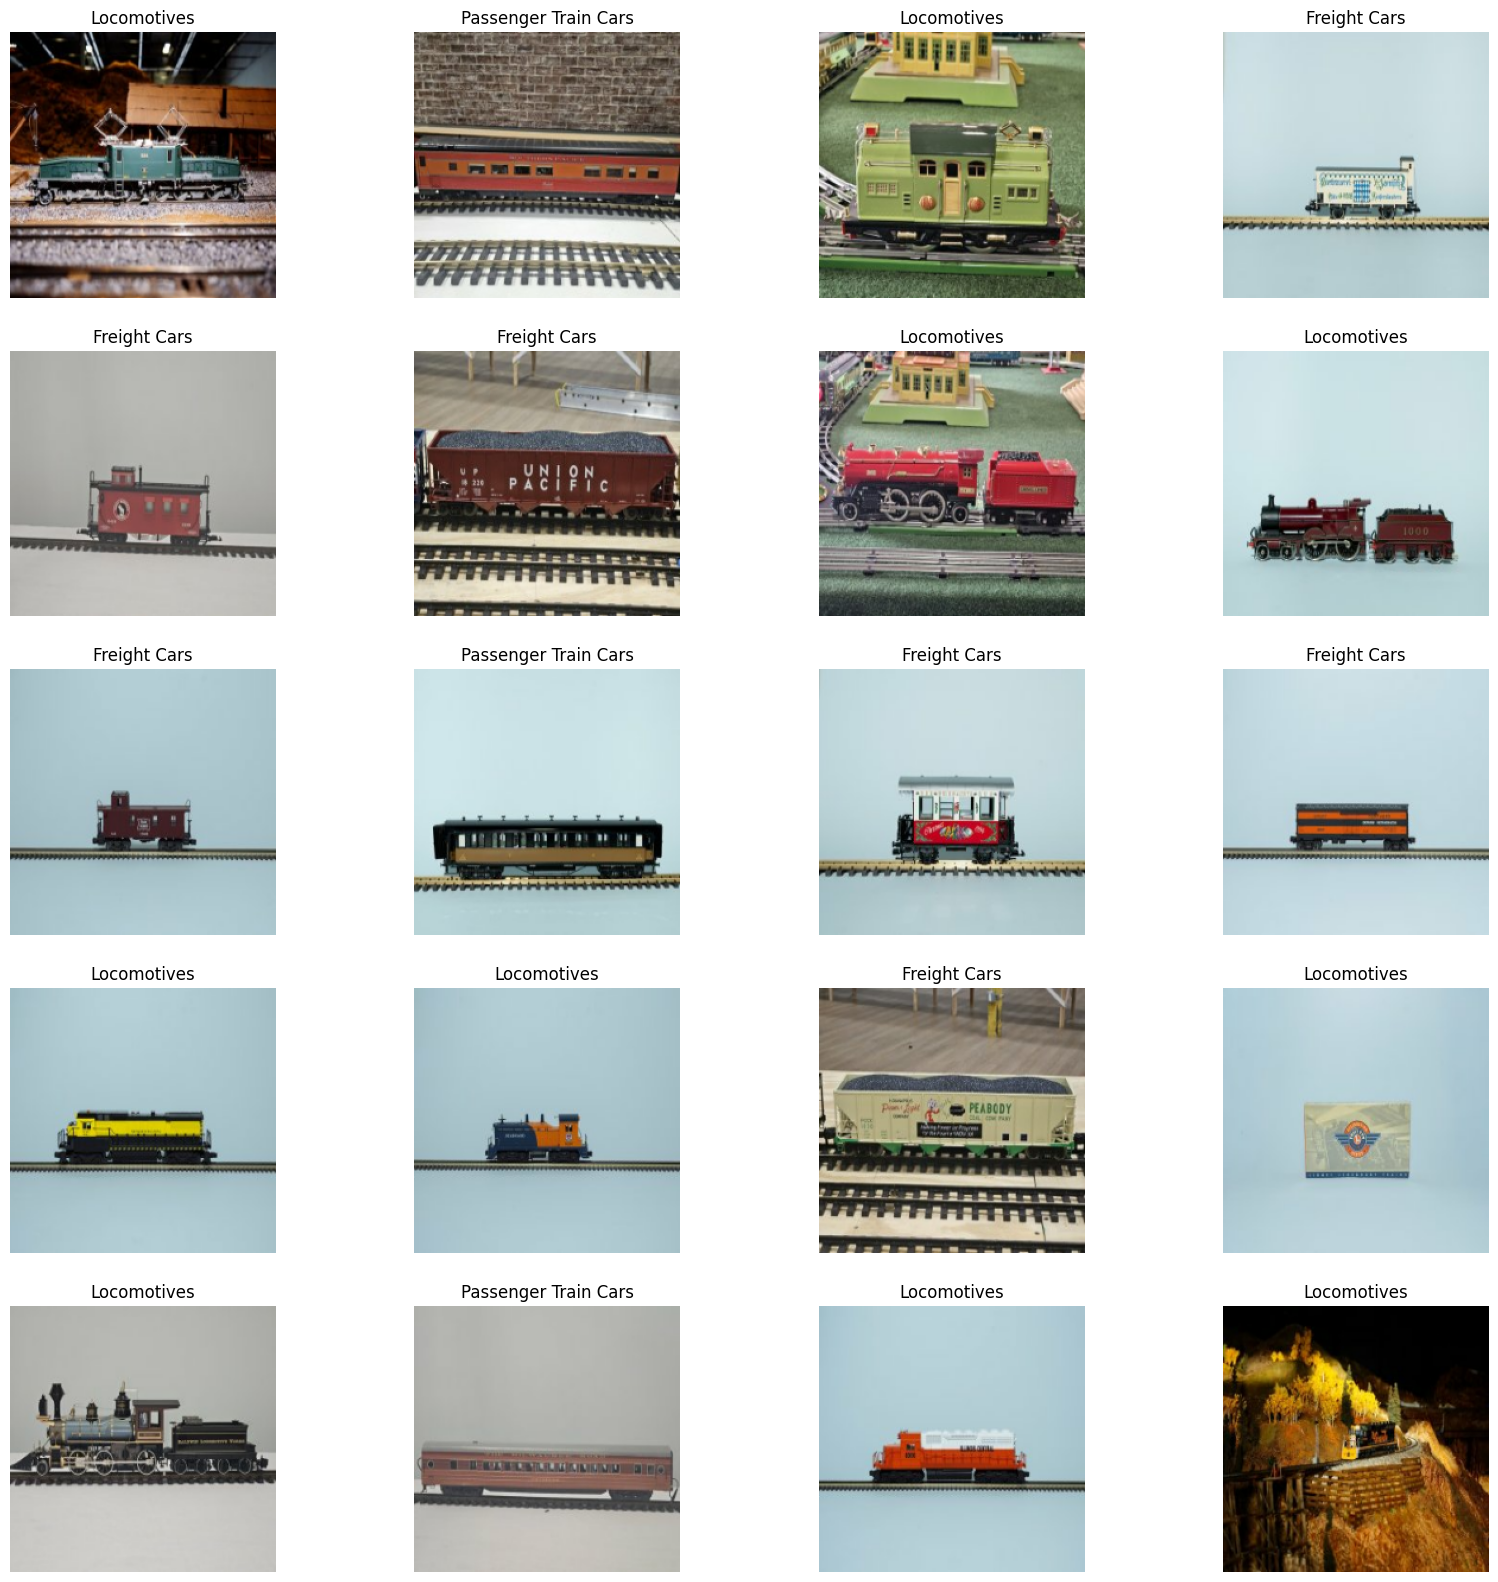

In [22]:
plt.figure(figsize=(20,20))
for image_batch , image_label in train_ds.take(1):
    for i in range(20):
        plt.subplot(5,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_labels[image_label[i].numpy()])
        plt.axis("off")

## More Libraries

"pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81."

In [23]:
%matplotlib inline
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from sklearn.model_selection import train_test_split

import cv2
#from google.colab.patches import cv2_imshow
from PIL import Image 
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense,Conv2D , MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory

import tensorflow_hub as hub

/usr/local/lib/python3.12/dist-packages/tensorflow_hub/__init__.py:61: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



## Resizing and Rescaling

In [24]:
resizing_and_rescaling = tf.keras.Sequential([
    tf.keras.layers.Resizing(224,224),
    tf.keras.layers.Rescaling(1.0/255)
])

## Data Augmentation

### AttributeError: module 'keras._tf_keras.keras.layers' has no attribute 'experimental'

Remove the **experimental.preprocessing** from tf.keras.layers.experimental.preprocessing.

In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomRotation(0.2)
])

In [27]:
#https://stackoverflow.com/questions/78530756/error-only-instances-of-keras-layer-can-be-added-to-a-sequential-model
#answered By Abhishek Mar 29, 2025 at 12:43

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

IMAGE_SHAPE = (224, 224)

efficientnet_link ="https://tfhub.dev/google/efficientnet/b0/classification/1"
efficientnet_layer = hub.KerasLayer(efficientnet_link,
                                    trainable=False,
                                    name="efficientnet")
class Efficientnet(layers.Layer):
  def call(self, inputs):
    return efficientnet_layer(inputs)

model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)), 
    Efficientnet(),  # Apply custom encoding layer
    layers.Dense(128, activation='relu'),  # Hidden layer 1
    layers.Dense(64, activation='relu'),  # Hidden layer 2
    layers.Dense(4, activation='softmax')  # Output layer We have 4 classes

])

In [28]:
#https://stackoverflow.com/questions/78530756/error-only-instances-of-keras-layer-can-be-added-to-a-sequential-model
#answered By Abhishek Mar 29, 2025 at 12:43

# Compile the model
model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy', #sparse_categorical_crossentropy
                    metrics=['accuracy'], 
                    jit_compile=False) # 🚨 Disable JIT compilation to avoid XLA-related issues

In [29]:
# Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnet (Efficientnet)     │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,644 (533.77 KB)

 Trainable params: 136,644 (533.77 KB)

 Non-trainable params: 0 (0.00 B)

## Epochs

Started 11:06 till 11:12

In [30]:
history = model.fit(train_ds ,
          batch_size=32, epochs=10, validation_data=test_ds)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.3328 - loss: 1356.0442 - val_accuracy: 0.3957 - val_loss: 552.8759
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.4500 - loss: 725.2361 - val_accuracy: 0.5187 - val_loss: 395.3792
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5578 - loss: 438.6068 - val_accuracy: 0.5561 - val_loss: 321.1583
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5938 - loss: 389.2855 - val_accuracy: 0.5775 - val_loss: 330.6853
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5906 - loss: 286.4102 - val_accuracy: 0.6096 - val_loss: 238.3443
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6344 - loss: 119.9489 - val_accuracy: 0.6471 - val_loss: 166.2645
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7328 - loss: 257.4995 - val_accuracy: 0.7219 - val_loss: 156.0155
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7234 - loss: 134.6984 - v

## Evaluate model

In [31]:
#By Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

loss, acc = model.evaluate(train_ds)
print("Loss on Train Data:",loss)
print("Accuracy on Train Data:",acc)
print()
val_loss, val_acc = model.evaluate(test_ds)
print("Loss on Test Data:",val_loss)
print("Accuracy on Test Data:",val_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7781 - loss: 66.3548
Loss on Train Data: 66.35475158691406
Accuracy on Train Data: 0.778124988079071

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7594 - loss: 77.1126
Loss on Test Data: 77.11257934570312
Accuracy on Test Data: 0.759358286857605


## History

In [32]:
#By Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"] 

loss = history.history["loss"]
val_loss = history.history["val_loss"]

## Accuracy and Loss

It seems that my (training/validation) curves are climbing up till 8 Epochs.

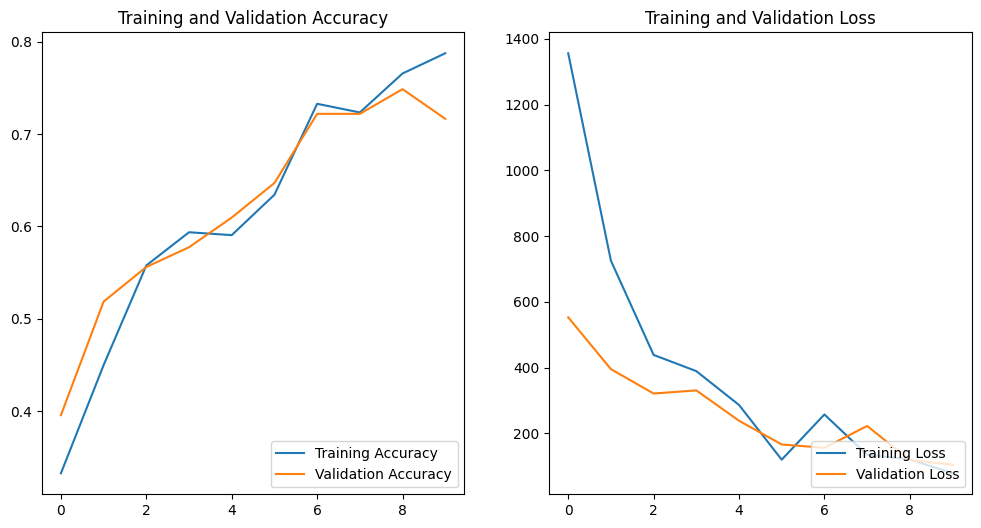

In [33]:
#By Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

EPOCHS=10
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc, label="Training Accuracy")
plt.plot(range(EPOCHS),val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

#plt.figure(figsize=(6,6))
plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss, label="Training Loss")
plt.plot(range(EPOCHS),val_loss, label="Validation Loss")
plt.legend(loc="lower right")
plt.title("Training and Validation Loss")
plt.show()

## Function to Predict images

In [34]:
def Prediction(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array((images[i].numpy()))
    img_array = tf.expand_dims(img_array,0)     # create a batch

    predictions = model.predict(img_array)

    predicted_class = class_labels[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])),2)

    return predicted_class , confidence

## Actual and Predicted Images of Locomotives

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


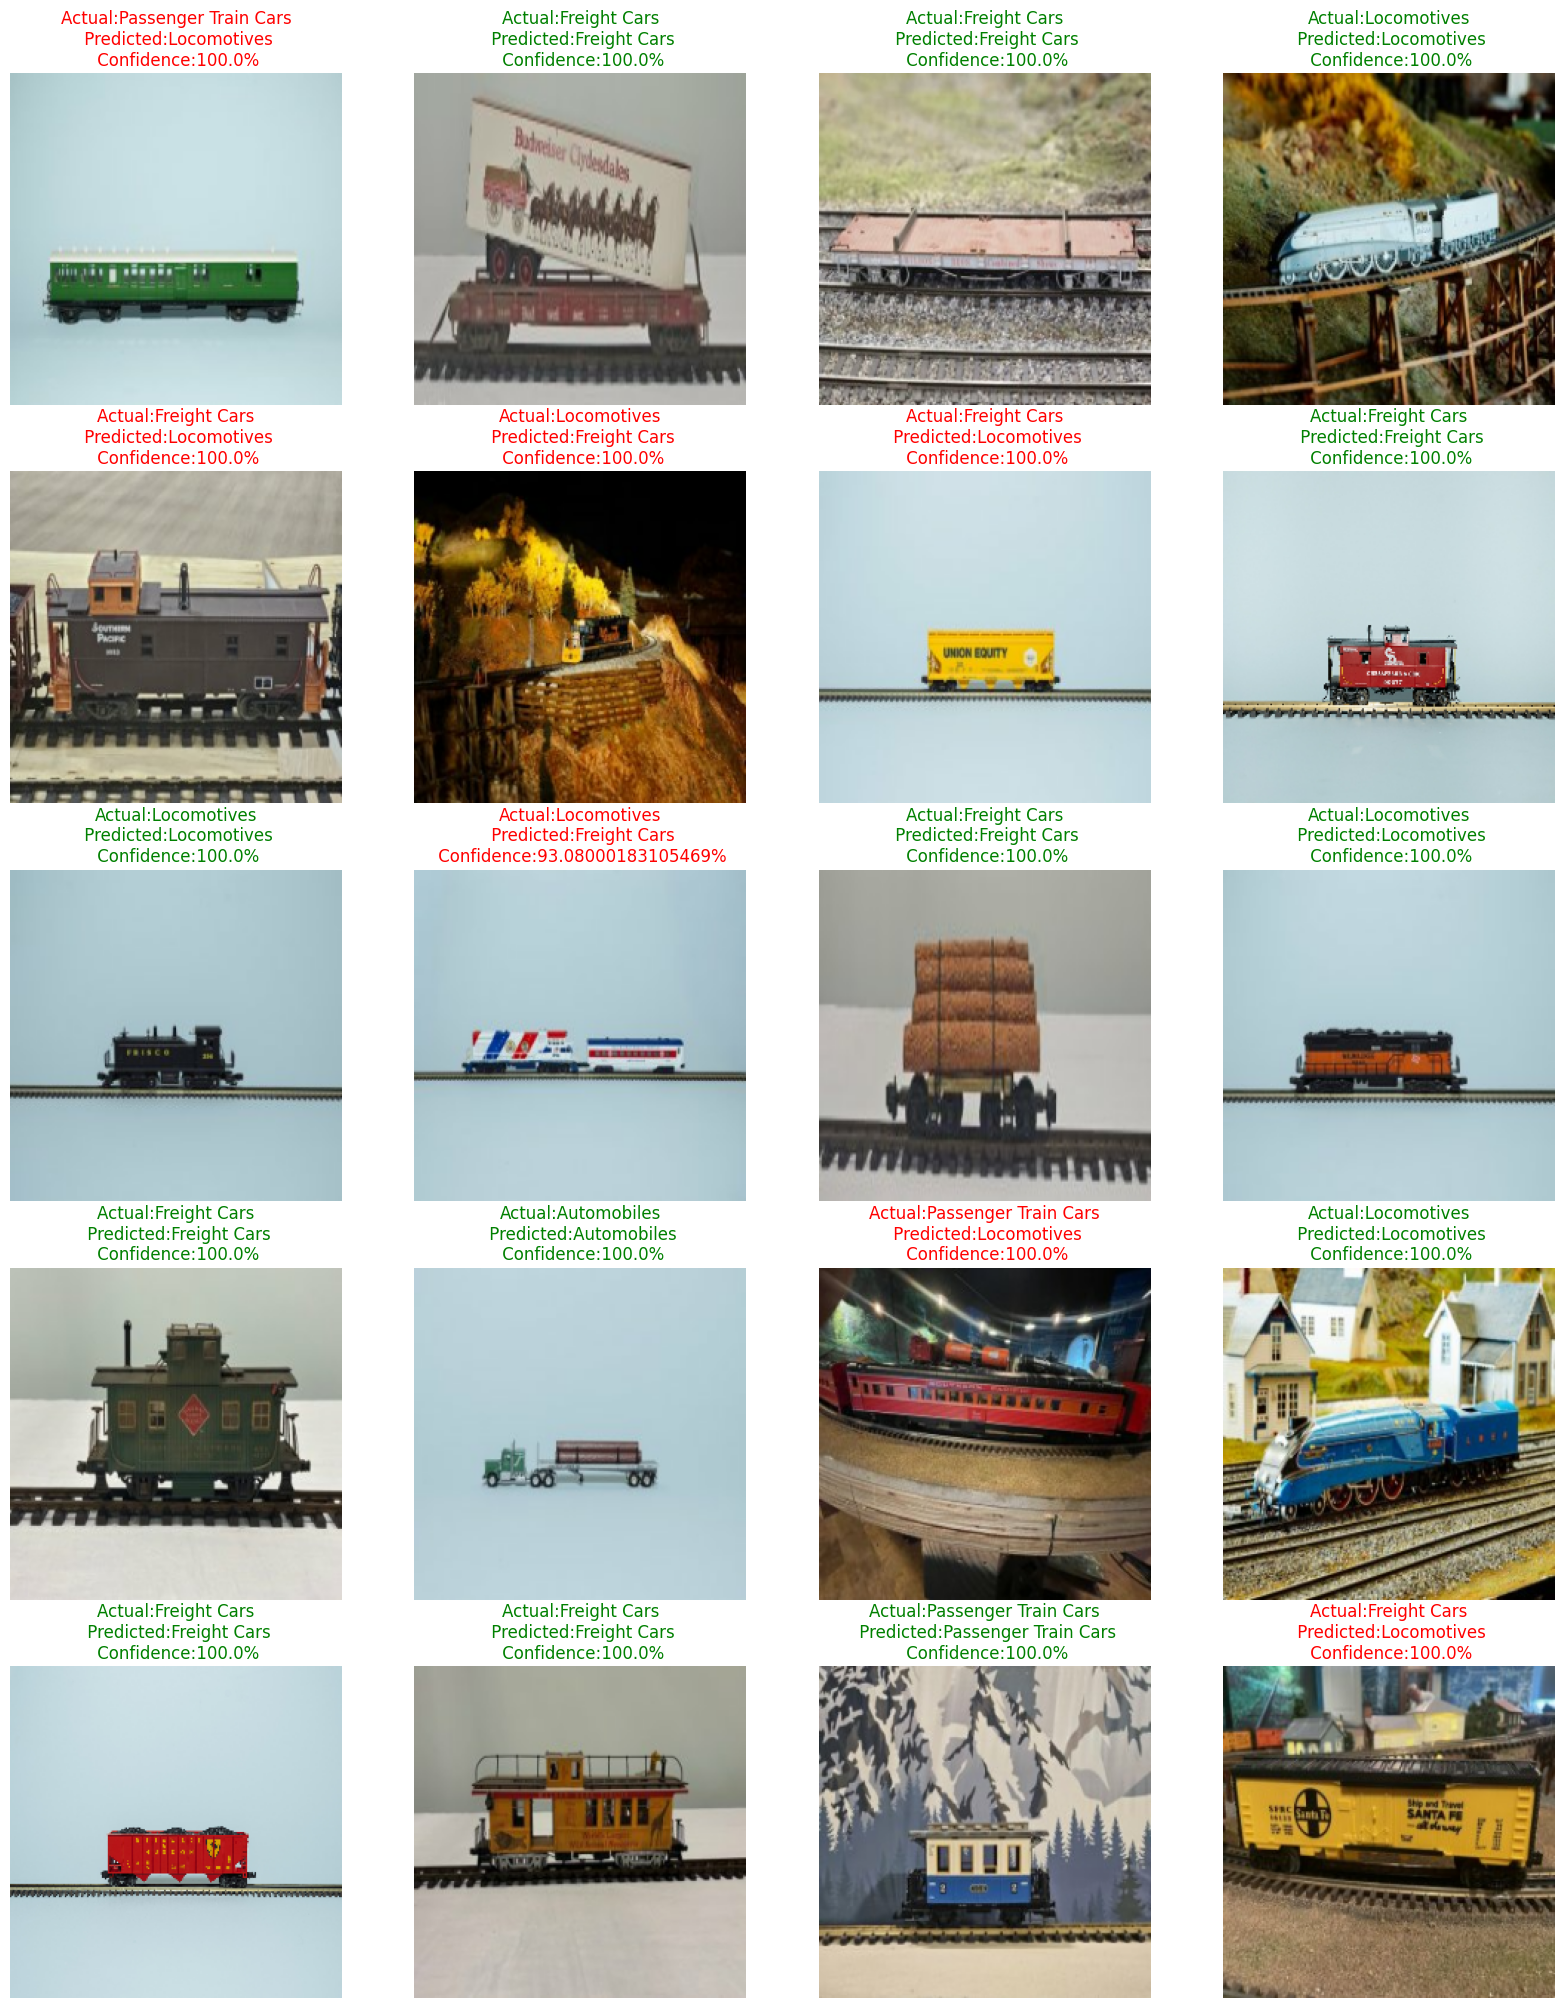

In [36]:
#By Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

plt.figure(figsize=(20,25))
for images , labels in test_ds.take(1):
    for i in range(20):
        ax = plt.subplot(5,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        #plt.title(class_label[labels[i]])


        predicted_class , confidence = Prediction(model, images[i].numpy())
        actual_class = class_labels[labels[i]]

        title_color = "green" if actual_class == predicted_class else "red"
        plt.title(f"Actual:{actual_class}\n Predicted:{predicted_class}\n Confidence:{confidence}%", color=title_color)
        plt.axis("off")

## Draft Session: 1h:37m

![](https://media1.tenor.com/m/Vmc5USgG-Q4AAAAd/tbbt-the-big-bang-theory.gif)


### Thirteen correct predictions out of twenty. 

#### I'm getting better. Woo, woo!

#Acknowledgements:

StackOverflow (Abhishek) https://stackoverflow.com/questions/78530756/error-only-instances-of-keras-layer-can-be-added-to-a-sequential-model  

AI Overview

Sunil Thite https://www.kaggle.com/code/sunilthite/dogbreeds-classification-using-pre-trained-model/notebook

mpwolke https://www.kaggle.com/code/mpwolke/berry-images-efficientnet/notebook